[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/anderson-perez/IAC/blob/main/Aprendizado%20Profundo/Redes_CNN_com_Pytorch.ipynb)

# Inteligência Artificial e Computacional

## Segunda Parte da Disciplina

# Informações:

- Prof. Anderson Luiz Fernandes Perez
- Contato: anderson.perez@ufsc.br | anderson.lfp@gmail.com
- Os materiais da disciplina estarão disponíveis no github (https://github.com/anderson-perez/IAC.git)

# Redes Convolucionais (CNN - Convolutional Neural Netowork)

Uma **Rede Neural Convolucional**, ou **CNN**, é uma arquitetura de deep learning muito utilizada em problemas de visão computacional.



É especialmente adequada para imagens porque explora a estrutura espacial dos dados. Em uma imagem, pixels vizinhos normalmente possuem relação entre si. As CNNs usam essa característica para aprender padrões locais, como:

- bordas;
- cantos;
- texturas;
- formas;
- partes de objetos;
- objetos completos.

Uma arquitetura típica de CNN possui:

```text
Imagem de entrada
      ↓
Camadas convolucionais
      ↓
Funções de ativação
      ↓
Pooling
      ↓
Flatten
      ↓
Camadas totalmente conectadas
      ↓
Classe prevista
```

## Exemplo CNN com Pytorch

- `torch`: biblioteca principal do PyTorch;
- `torch.nn`: construção de redes neurais;
- `torch.optim`: algoritmos de otimização;
- `torchvision`: datasets e transformações para imagens;
- `matplotlib`: visualização de imagens e gráficos.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
import numpy as np

O PyTorch permite executar os cálculos na CPU ou na GPU. No Google Colab, é possível ativar uma GPU em:

```text
Ambiente de execução → Alterar o tipo de ambiente de execução → GPU
```

O código abaixo verifica se há GPU disponível.

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo utilizado:", device)

Dispositivo utilizado: cpu


## Imagens como Tensores

Uma imagem digital pode ser representada como uma matriz de pixels.

Uma imagem em escala de cinza possui normalmente o formato:

$$
H \times W
$$

onde:

- $(H)$ é a altura;
- $(W)$ é a largura.

No PyTorch, uma imagem geralmente é representada como tensor no formato:

$$
C \times H \times W
$$

onde:

- $(C)$ é o número de canais;
- $(H)$ é a altura;
- $(W)$ é a largura.

Exemplos:

- imagem em escala de cinza: `1 x 28 x 28`;
- imagem RGB: `3 x 32 x 32`.

Formato da imagem: torch.Size([1, 8, 8])


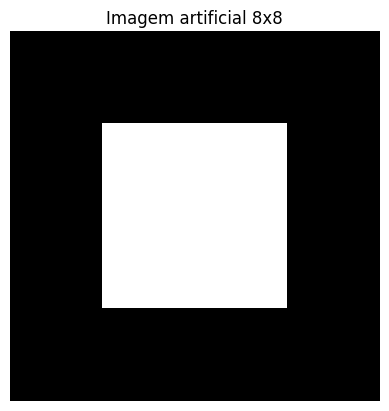

In [4]:
# Exemplo: imagem artificial simples: 1 canal, 8x8 pixels
imagem = torch.zeros((1, 8, 8))
imagem[:, 2:6, 2:6] = 1.0

print("Formato da imagem:", imagem.shape)

plt.imshow(imagem.squeeze(), cmap="gray")
plt.title("Imagem artificial 8x8")
plt.axis("off")
plt.show()

## Definição de Convolução

A convolução aplica um pequeno filtro, também chamado de **kernel**, sobre a imagem.

Um filtro percorre a imagem procurando determinados padrões. Por exemplo, um filtro pode detectar:

- bordas verticais;
- bordas horizontais;
- mudanças bruscas de intensidade;
- regiões claras ou escuras.

Em uma CNN, os valores dos filtros são **aprendidos automaticamente** durante o treinamento.

## Operação conceitual

Para cada região local da imagem, a CNN calcula uma combinação entre os pixels da região e os pesos do filtro.

O resultado é chamado de **mapa de características** ou **feature map**.

Formato de entrada: torch.Size([1, 1, 8, 8])
Formato de saída: torch.Size([1, 1, 6, 6])


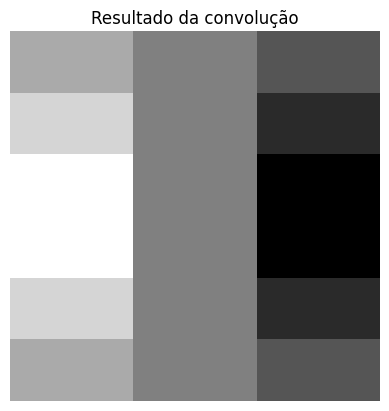

In [5]:
# Exemplo manual de uma convolução usando Conv2d
conv = nn.Conv2d(
    in_channels=1,
    out_channels=1,
    kernel_size=3,
    bias=False
)

# Definindo manualmente um filtro simples para detectar bordas verticais
filtro = torch.tensor([[[[-1., 0., 1.],
                        [-1., 0., 1.],
                        [-1., 0., 1.]]]])

conv.weight.data = filtro

# Conv2d espera entrada no formato: batch_size x canais x altura x largura
entrada = imagem.unsqueeze(0)
saida = conv(entrada)

print("Formato de entrada:", entrada.shape)
print("Formato de saída:", saida.shape)

plt.imshow(saida.detach().squeeze(), cmap="gray")
plt.title("Resultado da convolução")
plt.axis("off")
plt.show()

## Parâmetros da Convolução

### Tamanho do Kernel

É o tamanho do filtro. Exemplos comuns:

- `3x3`;
- `5x5`;
- `7x7`.

### Stride

É o passo com que o filtro se desloca pela imagem.

- `stride=1`: desloca um pixel por vez;
- `stride=2`: desloca dois pixels por vez.

### Padding

Adiciona bordas artificiais à imagem. Isso permite controlar o tamanho da saída.

Em muitas CNNs, usa-se `padding=1` com `kernel_size=3` para manter a dimensão espacial da imagem.

### Número de filtros

Cada filtro aprende um tipo de padrão. Se uma camada possui 32 filtros, ela gera 32 mapas de características.

In [6]:
# Exemplo de formatos de saída com diferentes parâmetros
x = torch.randn(1, 1, 28, 28)

conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=0)
conv2 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1)
conv3 = nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1)

print("Entrada:", x.shape)
print("Sem padding:", conv1(x).shape)
print("Com padding=1:", conv2(x).shape)
print("Com stride=2 e padding=1:", conv3(x).shape)

Entrada: torch.Size([1, 1, 28, 28])
Sem padding: torch.Size([1, 16, 26, 26])
Com padding=1: torch.Size([1, 16, 28, 28])
Com stride=2 e padding=1: torch.Size([1, 16, 14, 14])


## Pooling

A camada de **pooling** reduz a dimensão espacial dos mapas de características.

O tipo mais comum é o **Max Pooling**, que seleciona o maior valor dentro de uma pequena janela.

Exemplo:

```python
nn.MaxPool2d(kernel_size=2, stride=2)
```

Esse tipo de pooling reduz uma imagem de `28x28` para `14x14`.

### Por que usar pooling?

- reduz o custo computacional;
- diminui o número de parâmetros nas camadas seguintes;
- torna o modelo menos sensível a pequenas variações espaciais;
- ajuda a reduzir overfitting.

In [7]:
pool = nn.MaxPool2d(kernel_size=2, stride=2)

x = torch.randn(1, 16, 28, 28)
y = pool(x)

print("Antes do pooling:", x.shape)
print("Depois do pooling:", y.shape)

Antes do pooling: torch.Size([1, 16, 28, 28])
Depois do pooling: torch.Size([1, 16, 14, 14])


# Exemplo: Dataset MNIST

O dataset **MNIST** contém imagens de dígitos manuscritos de 0 a 9.

Cada imagem possui dimensão `28 x 28` pixels em escala de cinza.

No PyTorch o dataset MNIST está em `torchvision.datasets.MNIST`.

In [8]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print("Amostras de treino:", len(train_dataset))
print("Amostras de teste:", len(test_dataset))

100%|██████████| 9.91M/9.91M [00:00<00:00, 41.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.19MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.4MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.71MB/s]

Amostras de treino: 60000
Amostras de teste: 10000


## DataLoader

O `DataLoader` é responsável por carregar os dados em mini-batches.

O uso de mini-batches é essencial no treinamento de redes neurais modernas.

Parâmetros importantes:

- `batch_size`: quantidade de amostras por lote;
- `shuffle=True`: embaralha os dados de treinamento;
- `num_workers`: número de processos usados para carregar os dados.

In [9]:
batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

images, labels = next(iter(train_loader))
print("Formato do batch de imagens:", images.shape)
print("Formato do batch de rótulos:", labels.shape)

Formato do batch de imagens: torch.Size([64, 1, 28, 28])
Formato do batch de rótulos: torch.Size([64])


## Visualização das Imagens no Dataset

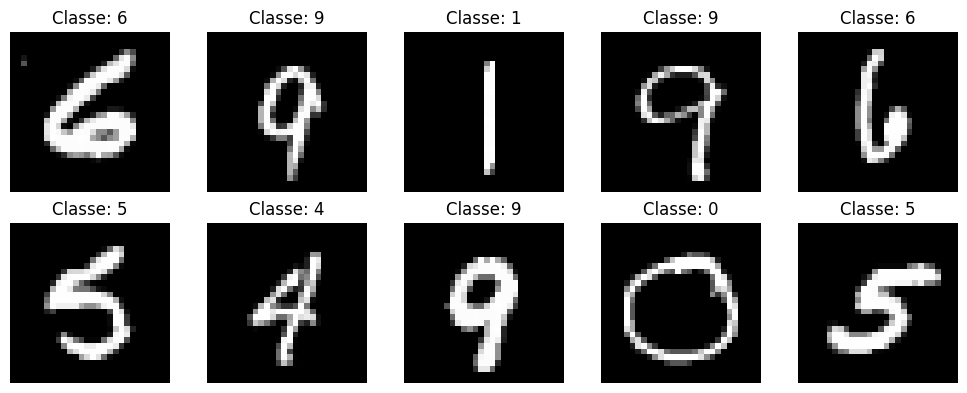

In [10]:
classes = [str(i) for i in range(10)]

plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.title(f"Classe: {labels[i].item()}")
    plt.axis("off")
plt.tight_layout()
plt.show()

## Construção da CNN com PyTorch

A arquitetura da rede será:

```text
Entrada: 1 x 28 x 28
      ↓
Conv2d: 1 → 16 filtros, kernel 3x3, padding 1
      ↓
ReLU
      ↓
MaxPool2d: 2x2
      ↓
Conv2d: 16 → 32 filtros, kernel 3x3, padding 1
      ↓
ReLU
      ↓
MaxPool2d: 2x2
      ↓
Flatten
      ↓
Linear
      ↓
Linear de saída com 10 neurônios
```

Depois de dois poolings, a imagem muda assim:

```text
28 x 28 → 14 x 14 → 7 x 7
```

Como a segunda convolução gera 32 mapas de características, a entrada da primeira camada linear será:

$$
32 \times 7 \times 7 = 1568
$$

In [12]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=16,
            kernel_size=3,
            padding=1
        )

        self.conv2 = nn.Conv2d(
            in_channels=16,
            out_channels=32,
            kernel_size=3,
            padding=1
        )

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)  # Flatten
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = CNN().to(device)
print(model)

CNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1568, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


## Função de Perda e Otimizador da Rede

Para classificação multiclasse em PyTorch, é comum usar:

```python
nn.CrossEntropyLoss()
```

Essa função já combina internamente:

- `Softmax`;
- cálculo da entropia cruzada.

Por isso, a última camada da rede deve retornar os **logits**, isto é, valores brutos antes da Softmax.

O algoritmo Adam será utilizado como otimizador.

In [13]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

## Processo de Treinamento

A função de treinamento executa os seguintes passos:

1. coloca o modelo em modo de treinamento com `model.train()`;
2. envia imagens e rótulos para CPU ou GPU;
3. calcula a saída da rede;
4. calcula o erro;
5. zera os gradientes acumulados;
6. calcula os gradientes com `loss.backward()`;
7. atualiza os pesos com `optimizer.step()`.

In [14]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

## Função de Avaliação

Durante a avaliação:

- usamos `model.eval()`;
- usamos `torch.no_grad()` para não calcular gradientes;
- calcula-se a perda e acurácia no conjunto de teste.

In [15]:
def evaluate(model, data_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

## Treinando a Rede



In [16]:
# Poucas épocas para fins didáticos
epochs = 5

train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    test_loss, test_acc = evaluate(
        model,
        test_loader,
        criterion,
        device
    )

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    test_losses.append(test_loss)
    test_accuracies.append(test_acc)

    print(f"Época {epoch+1}/{epochs}")
    print(f"Treino - Loss: {train_loss:.4f} | Acurácia: {train_acc:.4f}")
    print(f"Teste  - Loss: {test_loss:.4f} | Acurácia: {test_acc:.4f}")
    print("-" * 50)

Época 1/5
Treino - Loss: 0.1761 | Acurácia: 0.9464
Teste  - Loss: 0.0552 | Acurácia: 0.9813
--------------------------------------------------
Época 2/5
Treino - Loss: 0.0514 | Acurácia: 0.9839
Teste  - Loss: 0.0391 | Acurácia: 0.9865
--------------------------------------------------
Época 3/5
Treino - Loss: 0.0358 | Acurácia: 0.9889
Teste  - Loss: 0.0355 | Acurácia: 0.9874
--------------------------------------------------
Época 4/5
Treino - Loss: 0.0265 | Acurácia: 0.9913
Teste  - Loss: 0.0287 | Acurácia: 0.9898
--------------------------------------------------
Época 5/5
Treino - Loss: 0.0218 | Acurácia: 0.9928
Teste  - Loss: 0.0268 | Acurácia: 0.9910
--------------------------------------------------


## Curvas de Treinamento

As curvas de perda e acurácia ajudam a analisar o comportamento do modelo.

Alguns sinais importantes:

- perda de treino diminuindo: o modelo está aprendendo;
- perda de validação/teste aumentando: possível overfitting;
- acurácia baixa em treino e teste: possível underfitting;
- acurácia alta em treino e teste: boa generalização.

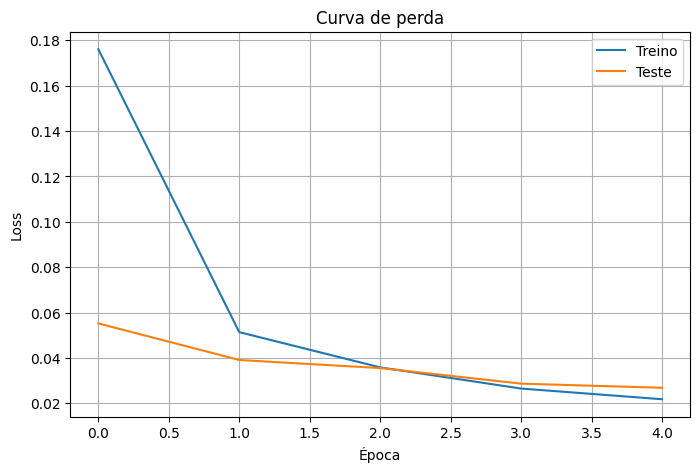

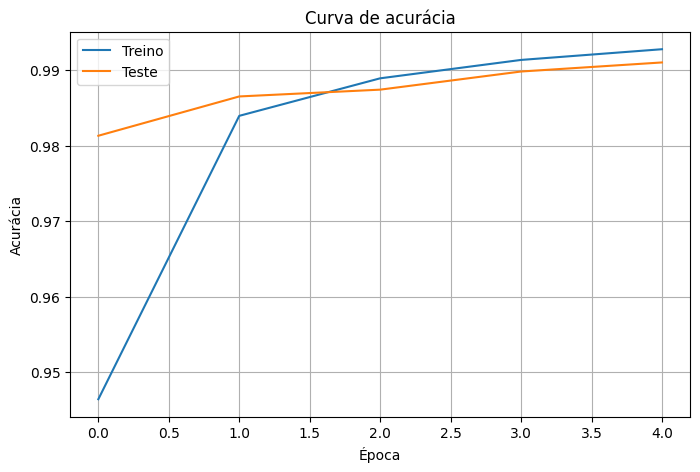

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Treino")
plt.plot(test_losses, label="Teste")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Curva de perda")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(train_accuracies, label="Treino")
plt.plot(test_accuracies, label="Teste")
plt.xlabel("Época")
plt.ylabel("Acurácia")
plt.title("Curva de acurácia")
plt.legend()
plt.grid(True)
plt.show()

## Fazendo Predições

Comparação:

- classe real;
- classe prevista pela CNN.

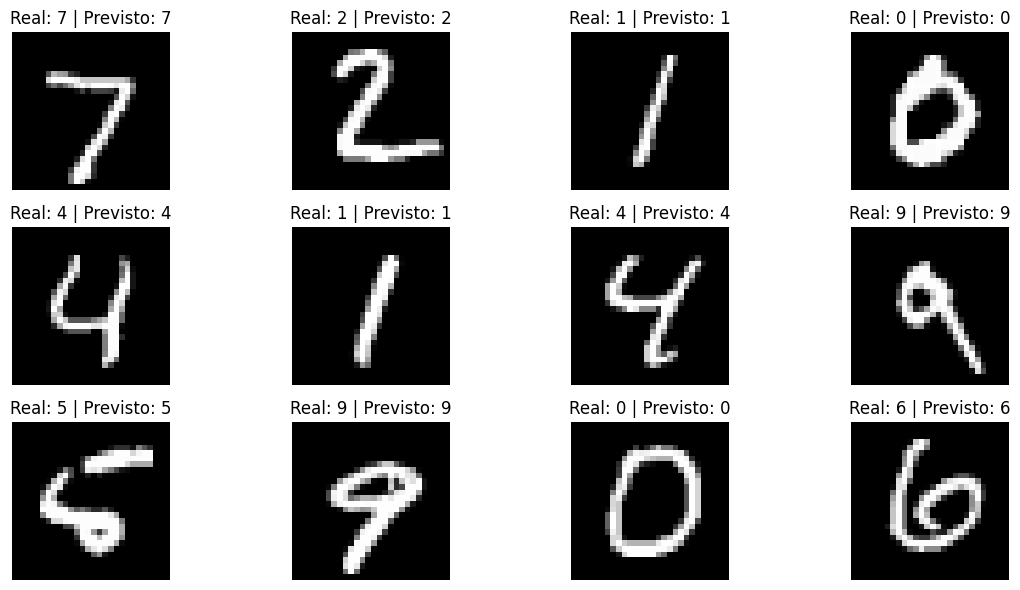

In [18]:
model.eval()

images, labels = next(iter(test_loader))
images_device = images.to(device)

with torch.no_grad():
    outputs = model(images_device)
    _, predicted = torch.max(outputs, 1)

plt.figure(figsize=(12, 6))
for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.title(f"Real: {labels[i].item()} | Previsto: {predicted[i].item()}")
    plt.axis("off")
plt.tight_layout()
plt.show()

## Matriz de Confusão

A matriz de confusão permite observar quais classes estão sendo confundidas pelo modelo.

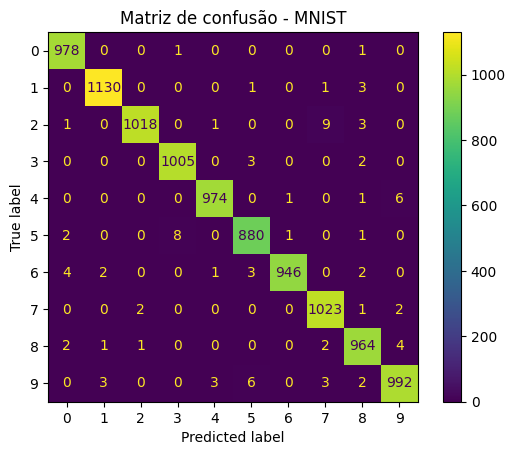

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(values_format="d")
plt.title("Matriz de confusão - MNIST")
plt.show()

## Mapas de Características

Nas CNNs é possível visualizar os mapas de características gerados pelas camadas convolucionais.

Formato dos mapas de características: torch.Size([16, 28, 28])


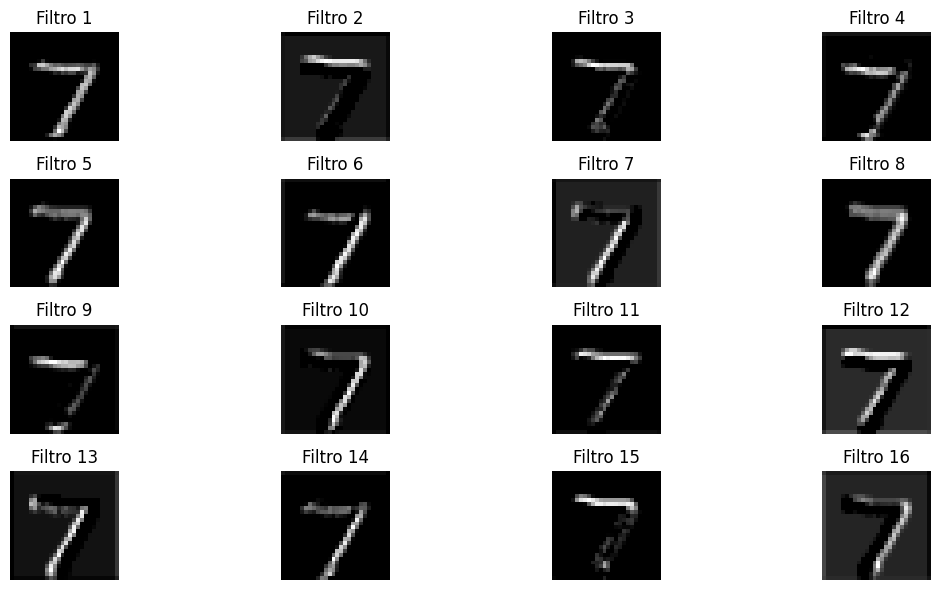

In [20]:
# Selecionando uma imagem do conjunto de teste
sample_image, sample_label = test_dataset[0]
sample_input = sample_image.unsqueeze(0).to(device)

# Passando apenas pela primeira convolução + ReLU
model.eval()
with torch.no_grad():
    feature_maps = F.relu(model.conv1(sample_input))

feature_maps = feature_maps.cpu().squeeze(0)

print("Formato dos mapas de características:", feature_maps.shape)

plt.figure(figsize=(12, 6))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(feature_maps[i], cmap="gray")
    plt.title(f"Filtro {i+1}")
    plt.axis("off")
plt.tight_layout()
plt.show()

## Salvando e Carregando o Modelo

É possível salvar os pesos do modelo usando `state_dict()`.

In [21]:
# Salvando os pesos do modelo
torch.save(model.state_dict(), "cnn_mnist_pytorch.pth")
print("Modelo salvo em cnn_mnist_pytorch.pth")

Modelo salvo em cnn_mnist_pytorch.pth


In [22]:
# Carregando os pesos em um novo modelo
new_model = CNN().to(device)
new_model.load_state_dict(torch.load("cnn_mnist_pytorch.pth", map_location=device))
new_model.eval()

print("Modelo carregado com sucesso.")

Modelo carregado com sucesso.


# Referências

* Mãos à Obra: aprendizado de máquina com scikit-learn, keras & tensorflow.

* Inteligência Artificial - uma abordagem de aprendizado de máquina.

* [Curso CNN Stanford University](https://stanford.edu/~shervine/teaching/cs-230/cheatsheet-convolutional-neural-networks/)

# Créditos

* As imagens foram geradas pelo chatgpt.